170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch	Loss
10	1.1048
20	1.0101
30	0.9412
40	0.8885
50	0.8487


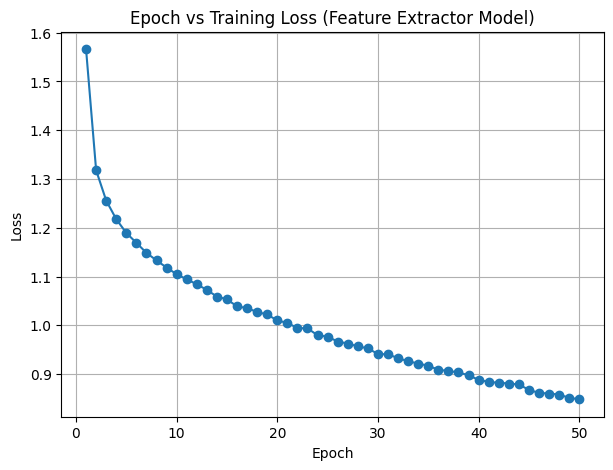

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train, 10), to_categorical(y_test, 10)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=0
)

print("Epoch\tLoss")
for epoch in [10, 20, 30, 40, 50]:
    loss = history.history['loss'][epoch - 1]
    print(f"{epoch}\t{loss:.4f}")

plt.figure(figsize=(7,5))
plt.plot(range(1, 51), history.history['loss'], marker='o')
plt.title('Epoch vs Training Loss (Feature Extractor Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()
